In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.13.0+cpu


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
# Load Dataset
df = pd.read_csv("cleaned_global_ecommerce_sales.csv")

# Check shape
print("Dataset Shape:", df.shape)

# Show first 5 rows
df.head()

Dataset Shape: (10000, 26)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [5]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  str    
 5   Season            10000 non-null  str    
 6   Customer_ID       10000 non-null  str    
 7   Customer_Gender   10000 non-null  str    
 8   Customer_Segment  10000 non-null  str    
 9   Region            10000 non-null  str    
 10  Country           10000 non-null  str    
 11  Category          10000 non-null  str    
 12  Sub_Category      10000 non-null  str    
 13  Product_Name      10000 non-null  str    
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64
 17  Reven

In [6]:
# Check Missing Values
print(df.isnull().sum())

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64


In [7]:
# Target Column
y = df["Order_Status"]

# Features
X = df.drop("Order_Status", axis=1)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 25)
Target Shape: (10000,)


In [8]:
# Convert Order_Date
X["Order_Date"] = pd.to_datetime(X["Order_Date"])

# Extract useful features
X["Day"] = X["Order_Date"].dt.day
X["Month"] = X["Order_Date"].dt.month
X["Weekday"] = X["Order_Date"].dt.dayofweek

# Drop original date column
X.drop("Order_Date", axis=1, inplace=True)

X.head()

,Order_ID,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Day,Weekday
0,ORD-000001,2023,1,Q1,Winter,CUST-02791,Male,New,North America,Mexico,...,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,18,2
1,ORD-000002,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,USA,...,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,13,0
2,ORD-000003,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,Canada,...,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,28,3
3,ORD-000004,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,Japan,...,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,22,4
4,ORD-000005,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,France,...,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,6,6


In [9]:
# Convert categorical columns into numeric
X = pd.get_dummies(X)

# Convert target into numeric
y = pd.factorize(y)[0]

print(X.shape)
print(y.shape)

(10000, 15497)
(10000,)


In [10]:
# Convert DataFrame to NumPy arrays
X = X.astype(np.float32).values
y = y.astype(np.int64)

# Convert NumPy arrays to PyTorch Tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)

print("Feature Tensor Shape:", X_tensor.shape)
print("Target Tensor Shape:", y_tensor.shape)

Feature Tensor Shape: torch.Size([10000, 15497])
Target Tensor Shape: torch.Size([10000])


In [11]:
# Define Multi-Layer Perceptron (MLP)

class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        return self.network(x)

In [12]:
# Number of input features
input_size = X_tensor.shape[1]

# Number of classes
output_size = len(torch.unique(y_tensor))

# Create model
model = MLP(input_size, output_size)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=15497, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [13]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
# Training Loop

losses = []

for epoch in range(20):

    # Reset gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_tensor)

    # Calculate loss
    loss = criterion(outputs, y_tensor)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch+1}/20, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 1.2301
Epoch 2/20, Loss: 1.1644
Epoch 3/20, Loss: 1.1699
Epoch 4/20, Loss: 1.1314
Epoch 5/20, Loss: 1.0799
Epoch 6/20, Loss: 1.0755
Epoch 7/20, Loss: 1.0828
Epoch 8/20, Loss: 1.0742
Epoch 9/20, Loss: 1.0694
Epoch 10/20, Loss: 1.0641
Epoch 11/20, Loss: 1.0612
Epoch 12/20, Loss: 1.0610
Epoch 13/20, Loss: 1.0605
Epoch 14/20, Loss: 1.0551
Epoch 15/20, Loss: 1.0508
Epoch 16/20, Loss: 1.0500
Epoch 17/20, Loss: 1.0502
Epoch 18/20, Loss: 1.0488
Epoch 19/20, Loss: 1.0482
Epoch 20/20, Loss: 1.0478


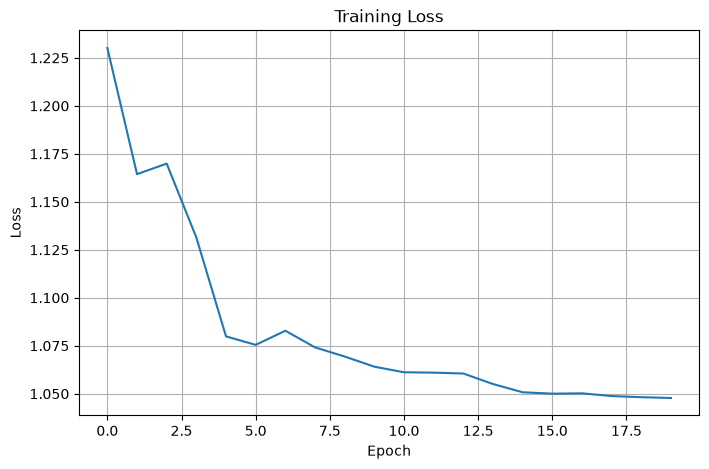

In [15]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [16]:
torch.save(model.state_dict(), "mlp_model.pth")
print("Model Saved Successfully!")

Model Saved Successfully!
